## Publication-Grade PCP (From Scratch – Matplotlib)

This gives you full control, unlike pandas.plotting.

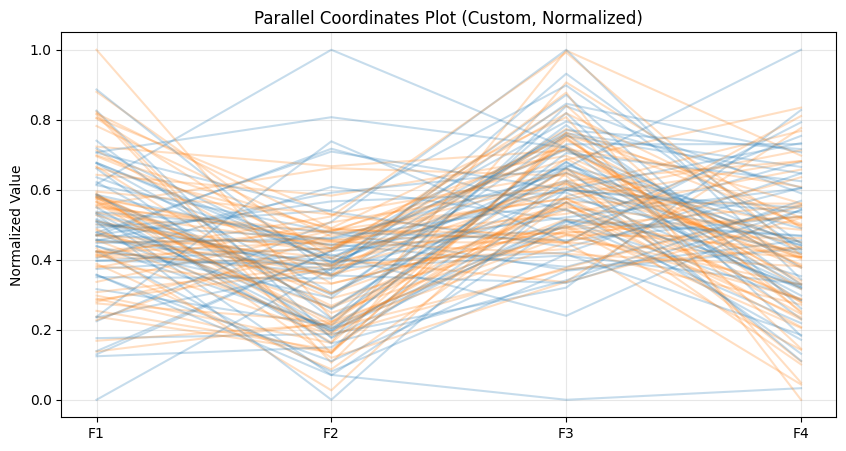

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Synthetic multivariate data
np.random.seed(42)
df = pd.DataFrame({
    "F1": np.random.normal(0, 1, 120),
    "F2": np.random.normal(2, 1.5, 120),
    "F3": np.random.normal(-1, 0.7, 120),
    "F4": np.random.normal(1, 1.2, 120),
    "Class": np.random.choice(["A", "B"], 120)
})

features = ["F1", "F2", "F3", "F4"]

# Normalize to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(df[features])

# Axis positions
x_pos = np.arange(len(features))

plt.figure(figsize=(10, 5))

for i in range(len(df)):
    color = "tab:blue" if df.loc[i, "Class"] == "A" else "tab:orange"
    plt.plot(x_pos, X[i], color=color, alpha=0.25)

plt.xticks(x_pos, features)
plt.ylabel("Normalized Value")
plt.title("Parallel Coordinates Plot (Custom, Normalized)")
plt.grid(alpha=0.3)
plt.show()


## Highlighting One Class / One Sample (Critical for ML)
🔹 Highlight class patterns

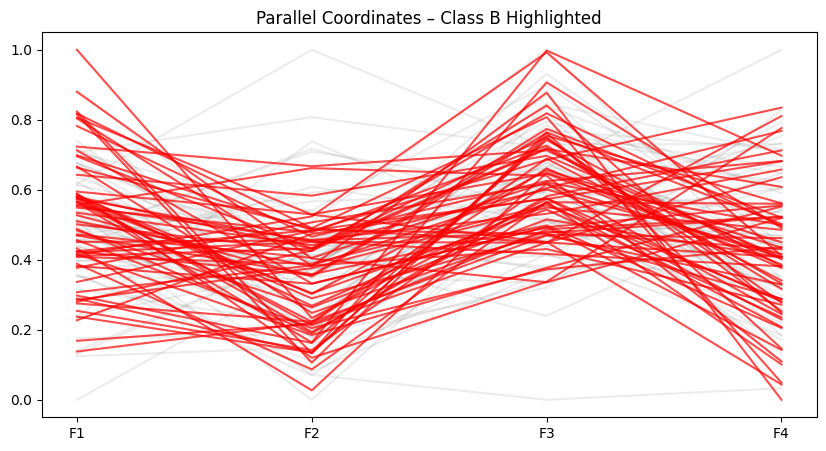

In [2]:
plt.figure(figsize=(10, 5))

for i in range(len(df)):
    if df.loc[i, "Class"] == "A":
        plt.plot(x_pos, X[i], color="gray", alpha=0.15)

# Highlight class B
for i in range(len(df)):
    if df.loc[i, "Class"] == "B":
        plt.plot(x_pos, X[i], color="red", alpha=0.7, linewidth=1.5)

plt.xticks(x_pos, features)
plt.title("Parallel Coordinates – Class B Highlighted")
plt.show()


## Axis Ordering (THIS CHANGES EVERYTHING)

PCP is highly sensitive to axis order.

🔹 Order by correlation

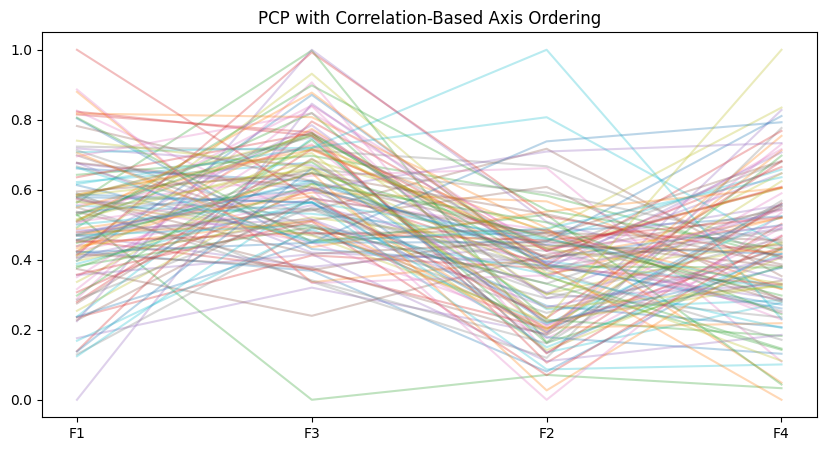

In [3]:
corr = df[features].corr()["F1"].abs().sort_values(ascending=False)
ordered_features = corr.index.tolist()

X_ord = scaler.fit_transform(df[ordered_features])
x_pos = np.arange(len(ordered_features))

plt.figure(figsize=(10, 5))
for i in range(len(df)):
    plt.plot(x_pos, X_ord[i], alpha=0.3)

plt.xticks(x_pos, ordered_features)
plt.title("PCP with Correlation-Based Axis Ordering")
plt.show()


## Parallel Coordinates for Outlier Detection

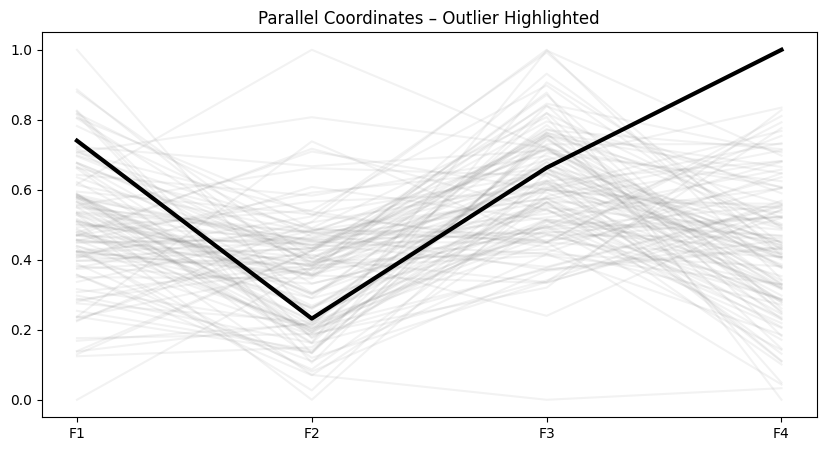

In [4]:
row_idx = np.argmax(np.linalg.norm(X, axis=1))  # extreme sample

plt.figure(figsize=(10, 5))
for i in range(len(df)):
    plt.plot(x_pos, X[i], color="gray", alpha=0.1)

plt.plot(x_pos, X[row_idx], color="black", linewidth=3)
plt.xticks(x_pos, features)
plt.title("Parallel Coordinates – Outlier Highlighted")
plt.show()


## PCP + Dimensionality Reduction (Power Combo)
🔹 Plot only top-variance features

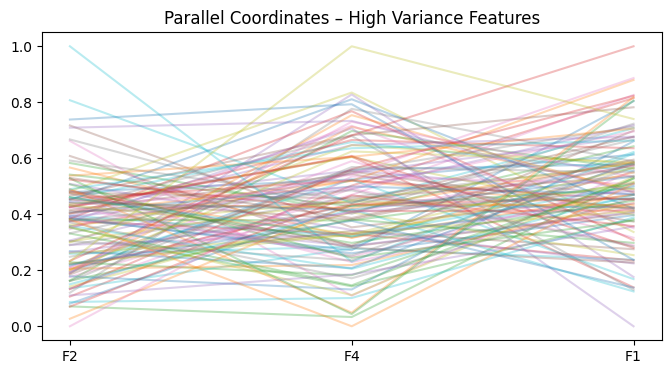

In [5]:
variances = df[features].var().sort_values(ascending=False)
top_features = variances.index[:3]

X_top = scaler.fit_transform(df[top_features])
x_pos = np.arange(len(top_features))

plt.figure(figsize=(8, 4))
for i in range(len(df)):
    plt.plot(x_pos, X_top[i], alpha=0.3)

plt.xticks(x_pos, top_features)
plt.title("Parallel Coordinates – High Variance Features")
plt.show()


## Interactive Parallel Coordinates (Exploration Mode)
🔹 Plotly (Brushing + Filtering)

In [6]:
import plotly.express as px

fig = px.parallel_coordinates(
    df,
    dimensions=features,
    color=(df["Class"] == "B").astype(int),
    color_continuous_scale=px.colors.diverging.Tealrose,
)

fig.show()
